<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
        - [3.1.1 Single-label VS Multi-label Classification](#P3.1.1)
        - [3.1.1 Similarity between restaurant categories](#P3.1.2)
        - [3.1.2 Empty Restaurant Reviews](#P3.1.3)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics


# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from classification_prep import *

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [7]:
#Next cells are already done in the data prep notebook
dataset["categoryName"].value_counts().reset_index()

,categoryName,count
0,Mexican restaurant,8959
1,Fast food restaurant,5325
2,Italian restaurant,5108
3,American restaurant,5049
4,Pizza restaurant,4560
5,Breakfast restaurant,2491
6,Chinese restaurant,2484
7,Seafood restaurant,2048
8,Hamburger restaurant,1979
9,New American restaurant,1903


In [8]:
## Create dummy columns to assess msg_len and nr_sents
info = pd.DataFrame()
info["msg_len"] = dataset["text"].map(lambda content : len(str(content)))
info["sents"] = dataset["text"].map(lambda content :\
                                                                  sent_tokenizer.tokenize(str(content)))
info["nr_sents"] = info["sents"].map(lambda content : len(content))

In [9]:
info.describe()
#is there reviews with 0 on len and 0 sentences?

,msg_len,nr_sents
count,53566.000000,53566.000000
mean,183.570380,3.246910
std,240.235404,3.085194
min,1.000000,1.000000
25%,46.000000,1.000000
50%,105.000000,2.000000
75%,228.000000,4.000000
max,4114.000000,45.000000


In [10]:
#this was already made on the data understanding notebook
#histogram_chart(info, "msg_len", "Length per review", "Message Length", bins = 100)

In [11]:
histogram_chart(info, "nr_sents", "Number of Sentences per review", "Number of Sentences")

In [12]:
# Extract the unique genres
unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

# Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["text"] = dataset["text"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

<Axes: >

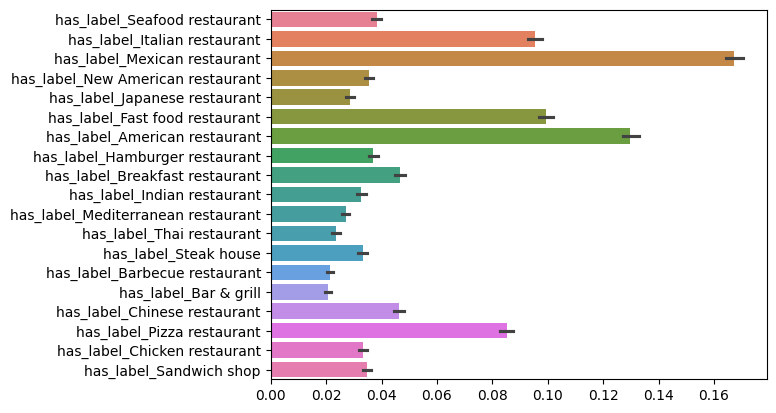

In [13]:
sns.barplot(dataset_explore, orient="h")

The restaurant category with the most comments is the "Italian Restaurant", and the one with the least is "Bar & Grill"

### <font color='#BFD72F' size=6>3.1.1 Single-label VS Multi-label Classification</font> <a class="anchor" id="P3.1.1"></a>
  
[Back to TOC](#toc)

In [14]:
# number of unique restaurant titles
len(dataset['title'].unique())

295

In [15]:
#grouping by restaurant to make sure that all the restaurants with the same name have category Name 
len(dataset.groupby('title')['categoryName'].unique())

295

The number of different restaurants is the same as when we group by category, so the category name is consistent between reviews.

In [16]:
max_len = max(dataset['categoryName'].apply(len))
max_len

24

In [17]:
#QUESTION: IS THIS EVEN A MULTICLASS CLASSIFICATION PROBLEM?
#show the comments that have a category longer than the longets categoty name available
dataset[dataset['categoryName'].apply(lambda x: len(x) > max_len)]

,title,categoryName,website,url,reviewsCount,stars,text


Since each review has exactly one and only one restaurant category (target) attributed to it, this is not a MULTI-LABEL multiclassification problem, but a SINGLE-LABEL multicalssification problem.

### <font color='#BFD72F' size=6>3.1.2 Similarity between restaurant categories</font> <a class="anchor" id="P3.1.2"></a>
  
[Back to TOC](#toc)

In [18]:
dataset['with_stopword_cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=False,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [19]:
category_reviews = dataset.groupby("categoryName")["with_stopword_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["with_stopword_cleaned_review_body"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

Analyizing first the similarity of the language used in the reviews between different categories before removing stop words.

In [20]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As we can see, the great majority of categories have a very high similarity between them, indicating that the language used in reviews across different restaurant categories is quite similar. This is do to the fact that the reviews contain a lot of stopwords and common words that are not specefic to the restaurant category, they are common words used in everyday language. If the text data isnt treated the model might have difficulties in distinguishing between the different categories.

In [21]:
dataset['cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            #stopwords
        stopwords_tokeep=["very"],
        extra_stopwords=["food", "good", "service", "experience", "staff", "back", "best"],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

Now analyzing the similarity again after removing stopwords and other common words across all reviews.

In [22]:
category_reviews_cleaned1 = dataset.groupby("categoryName")["cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix1 = vectorizer.fit_transform(category_reviews_cleaned1["cleaned_review_body"])

similarity_matrix_cleaned1 = cosine_similarity(tfidf_matrix1)

similarity_df_cleaned1 = pd.DataFrame(
    similarity_matrix_cleaned1,
    index=category_reviews_cleaned1["categoryName"],
    columns=category_reviews_cleaned1["categoryName"])

heatmap_chart(similarity_df_cleaned1,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As expected, after removing stopwords and common words in restaurant reviews, the similarity between categories decreases significantly. 
This indicates that the unique vocabulary associated with each restaurant category becomes more pronounced when generic terms are excluded, allowing for a clearer distinction in the language used across different types of restaurants. This is a great indicator that this treatment should be done before attempting the classification task.

After further analyzing the correlation matrix, three categories stand out as having higher similarity scores with each other: "New American restaurant", "American Restaurant", and "Steak house". This suggests that the language used in reviews for these categories shares more common terms and expressions compared to other categories. After further analyzing these Cousine Categories, it was concluded that they were very similar, therefore the three were joint into  one common categorie: "American & Steakhouse". For the rest of the exploration and calssification these categories will be seen as this new one created.

In [23]:
# joining the three categories into one : 'American & Steakhouse'
dataset['categoryName'] = dataset['categoryName'].replace({
    'American restaurant': 'American & Steakhouse',
    'New American restaurant': 'American & Steakhouse',
    'Steak house': 'American & Steakhouse'
})

In [24]:
'''cleaned_category_texts = {}

for category in dataset["categoryName"].unique():
    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()
    combined_text = " ".join(cat_texts)

    cleaned_text = main_pipeline(
        combined_text,
        print_output=False,
        no_stopwords=True,  # keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food","great","good","service","place",
                         "experience","delicious","staff","back","best"],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )

    cleaned_category_texts[category] = cleaned_text
'''

'cleaned_category_texts = {}\n\nfor category in dataset["categoryName"].unique():\n    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()\n    combined_text = " ".join(cat_texts)\n\n    cleaned_text = main_pipeline(\n        combined_text,\n        print_output=False,\n        no_stopwords=True,  # keep stopwords\n        stopwords_tokeep=[],\n        extra_stopwords=["food","great","good","service","place",\n                         "experience","delicious","staff","back","best"],\n        convert_diacritics=True,\n        lowercase=True,\n        lemmatized=True,\n        list_pos=[],\n        stemmed=False,\n        pos_tags_list=\'no_pos\',\n        tokenized_output=False,\n        no_emojis=True,\n        no_hashtags=True,\n        hashtag_retain_words=False,\n        no_newlines=True,\n        no_urls=True,\n        no_punctuation=True,\n        treat_repeated_chars=True\n    )\n\n    cleaned_category_texts[category] = cleaned_text\n'

In [25]:
'''df_low = dataset[dataset["stars"].isin([1, 2, 3])]
df_high = dataset[dataset["stars"].isin([4, 5])]


low_text = main_pipeline(
    " ".join(df_low["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
high_text = main_pipeline(
    " ".join(df_high["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
'''

'df_low = dataset[dataset["stars"].isin([1, 2, 3])]\ndf_high = dataset[dataset["stars"].isin([4, 5])]\n\n\nlow_text = main_pipeline(\n    " ".join(df_low["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\n    convert_diacritics=True,\n    lowercase=True,\n    lemmatized=True,\n    list_pos=[],\n    stemmed=False,\n    pos_tags_list=\'no_pos\',\n    tokenized_output=False,\n    no_emojis=True,\n    no_hashtags=True,\n    hashtag_retain_words=False,\n    no_newlines=True,\n    no_urls=True,\n    no_punctuation=True,\n    treat_repeated_chars=True\n)\nhigh_text = main_pipeline(\n    " ".join(df_high["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\

In [26]:
'''from collections import Counter

low_counts = Counter(low_text.split())
high_counts = Counter(high_text.split())

word_category_map = {}

all_words = set(low_counts.keys()) | set(high_counts.keys())

for word in all_words:
    if low_counts.get(word, 0) > high_counts.get(word, 0):
        word_category_map[word] = "negative"
    elif high_counts.get(word, 0) > low_counts.get(word, 0):
        word_category_map[word] = "positive"
    else:
        word_category_map[word] = "neutral"'''



'from collections import Counter\n\nlow_counts = Counter(low_text.split())\nhigh_counts = Counter(high_text.split())\n\nword_category_map = {}\n\nall_words = set(low_counts.keys()) | set(high_counts.keys())\n\nfor word in all_words:\n    if low_counts.get(word, 0) > high_counts.get(word, 0):\n        word_category_map[word] = "negative"\n    elif high_counts.get(word, 0) > low_counts.get(word, 0):\n        word_category_map[word] = "positive"\n    else:\n        word_category_map[word] = "neutral"'

In [27]:
'''def color_by_category(word, *args, **kwargs):
    category = word_category_map.get(word, "neutral")

    if category == "negative":
        return "rgb(220, 20, 60)"   # red
    elif category == "positive":
        return "rgb(34, 139, 34)"   # green
    else:
        return "rgb(120, 120, 120)" # gray'''



'def color_by_category(word, *args, **kwargs):\n    category = word_category_map.get(word, "neutral")\n\n    if category == "negative":\n        return "rgb(220, 20, 60)"   # red\n    elif category == "positive":\n        return "rgb(34, 139, 34)"   # green\n    else:\n        return "rgb(120, 120, 120)" # gray'

In [28]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

folder_path = "../images/visualizations/wordclouds"

for category, text in cleaned_category_texts.items():

    # TF-IDF
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()

    freq_dict = dict(zip(words, vector))

    # WordCloud
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        color_func=color_by_category
    ).generate_from_frequencies(freq_dict)

    wc.to_file(f"{folder_path}/wordcloud_{category.replace(' ', '_')}.png")'''



'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom wordcloud import WordCloud\n\nfolder_path = "../images/visualizations/wordclouds"\n\nfor category, text in cleaned_category_texts.items():\n\n    # TF-IDF\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n\n    freq_dict = dict(zip(words, vector))\n\n    # WordCloud\n    wc = WordCloud(\n        width=1600,\n        height=800,\n        background_color="white",\n        color_func=color_by_category\n    ).generate_from_frequencies(freq_dict)\n\n    wc.to_file(f"{folder_path}/wordcloud_{category.replace(\' \', \'_\')}.png")'

In [29]:
'''# Folder to save WordCloud images
folder_path = '../images/visualizations/wordclouds'

# Generating a WordCloud for each category
for category, text in cleaned_category_texts.items():
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()
    
    tfidf_df = pd.DataFrame([vector], columns=words)
    
    wordcloud_from_vectorized(
        folder_path=folder_path,
        filename=f"wordcloud_{category.replace(' ', '_')}.png",
        vectorized_df=tfidf_df,
        top_n=100  
    )'''



'# Folder to save WordCloud images\nfolder_path = \'../images/visualizations/wordclouds\'\n\n# Generating a WordCloud for each category\nfor category, text in cleaned_category_texts.items():\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n    \n    tfidf_df = pd.DataFrame([vector], columns=words)\n    \n    wordcloud_from_vectorized(\n        folder_path=folder_path,\n        filename=f"wordcloud_{category.replace(\' \', \'_\')}.png",\n        vectorized_df=tfidf_df,\n        top_n=100  \n    )'

In [30]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,great,814
1,Seafood restaurant,very,489
2,Seafood restaurant,place,358
3,Seafood restaurant,seafood,350
4,Seafood restaurant,shrimp,337
5,Seafood restaurant,time,321
6,Seafood restaurant,delicious,248
7,Seafood restaurant,restaurant,245
8,Seafood restaurant,amazing,228
9,Seafood restaurant,fish,226


In [31]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

Looking at this graph, it is evident that some more general words are still present in the top 15 words per category, such as "like", "great". These words may not provide significant discriminatory power for classification tasks, as they are commonly used across various contexts. It might be beneficial to further refine the stopword list or apply additional filtering techniques to remove such generic terms, thereby enhancing the focus on more category-specific vocabulary.

### <font color='#BFD72F' size=6>3.1.3 Empty Restaurant Reviews</font> <a class="anchor" id="P3.1.3"></a>
  
[Back to TOC](#toc)

After preprocessing the text data, the removal of certain stop words and generic terms caused some observations to become empty, as they were composed entirely of words labeled as noise. As a result, these observations now contain no meaningful content. It is therefore essential to identify and remove them from the dataset, since it is impossible to predict a category when no data remains to base the prediction on.

In [32]:
# Count the number of exactly empty reviews
empty_exact = (dataset["with_stopword_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces = dataset["with_stopword_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples = dataset[dataset["with_stopword_cleaned_review_body"].str.strip() == ""]["with_stopword_cleaned_review_body"].head(10)
print("Exactly empty reviews:", empty_exact)
print("Reviews with only spaces (or tabs):", empty_spaces)
print("\nExamples of empty reviews:")
print(examples)

Exactly empty reviews: 9
Reviews with only spaces (or tabs): 9

Examples of empty reviews:
4854     
13836    
18086    
21008    
22216    
29289    
42324    
42803    
44987    
Name: with_stopword_cleaned_review_body, dtype: object


In [33]:
# Count the number of exactly empty reviews
empty_exact1 = (dataset["cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces1 = dataset["cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples1 = dataset[dataset["cleaned_review_body"].str.strip() == ""]["cleaned_review_body"].head(10)

print("Exactly empty reviews:", empty_exact1)
print("Reviews with only spaces (or tabs):", empty_spaces1)
print("\nExamples of empty reviews:")
print(examples1)

Exactly empty reviews: 538
Reviews with only spaces (or tabs): 538

Examples of empty reviews:
69      
266     
851     
1089    
1130    
1191    
1324    
1469    
1993    
2420    
Name: cleaned_review_body, dtype: object


In [34]:
empty_idx = dataset[dataset["with_stopword_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx, :]

,title,categoryName,website,url,reviewsCount,stars,text,with_stopword_cleaned_review_body,cleaned_review_body
4854,Flower Child,American & Steakhouse,https://www.iamaflowerchild.com/locations/sand...,https://www.google.com/maps/place/Flower+Child...,829,5.0,❤️,,
13836,Buon Fornello Café & Bottega,Italian restaurant,http://www.buonfornello.com/,https://www.google.com/maps/place/Buon+Fornell...,332,5.0,#fresheats #greatfood #authenticitalianfood #g...,,
18086,Carrabba's Italian Grill,Italian restaurant,https://locations.carrabbas.com/georgia/cummin...,https://www.google.com/maps/place/Carrabba's+I...,1059,5.0,✔️,,
21008,Dairy Queen Grill & Chill,Fast food restaurant,https://www.dairyqueen.com/en-us/locations/ga/...,https://www.google.com/maps/place/Dairy+Queen+...,1184,5.0,⭐⭐⭐⭐⭐,,
22216,La Zacatecana Taqueria,Mexican restaurant,https://la-zacatecana-taqueria.business.site/,https://www.google.com/maps/place/La+Zacatecan...,537,5.0,☝,,
29289,Wendy's,Fast food restaurant,https://locations.wendys.com/united-states/ga/...,https://www.google.com/maps/place/Wendy's/@34....,628,5.0,️,,
42324,Carrabba's Italian Grill,Italian restaurant,https://locations.carrabbas.com/georgia/peacht...,https://www.google.com/maps/place/Carrabba's+I...,1531,5.0,❤️❤️❤️❤️,,
42803,Krystal,Fast food restaurant,https://locations.krystal.com/ga/marietta/271-...,https://www.google.com/maps/place/Krystal/@33....,1163,5.0,❤️,,
44987,El Velero Seafood & Mexican,Mexican restaurant,http://el-velero-seafood.poi.place/,https://www.google.com/maps/place/El+Velero+Se...,51,5.0,♥️,,


In [35]:
#removing the empty reviews
dataset.drop(empty_idx, inplace=True)

In [36]:
# celula duplicada?? APAGAR
empty_idx = dataset[dataset["cleaned_review_body"].str.strip() == ""].index

# Mostrar todas as colunas das linhas vazias
dataset.loc[empty_idx, :]

,title,categoryName,website,url,reviewsCount,stars,text,with_stopword_cleaned_review_body,cleaned_review_body
69,Nino's Italian Restaurant,Italian restaurant,https://ninosatlanta.com/?y_source=1_MTQxNzM5N...,https://www.google.com/maps/place/Nino's+Itali...,643,5.0,Food was good.,food was good,
266,Longleaf Restaurant,American & Steakhouse,https://atlantabg.org/plan-your-visit/dining-a...,https://www.google.com/maps/place/Longleaf+Res...,327,4.0,Good food,good food,
851,El Azteca,Mexican restaurant,http://www.elaztecaatlanta.com/buckhead,https://www.google.com/maps/place/El+Azteca/@3...,1496,3.0,The food was not all that,the food was not all that,
1089,NaanStop,Indian restaurant,http://naanstop.com/,https://www.google.com/maps/place/NaanStop/@33...,490,4.0,Good food,good food,
1130,NaanStop,Indian restaurant,http://naanstop.com/,https://www.google.com/maps/place/NaanStop/@33...,490,5.0,Good food and service,good food and service,
...,...,...,...,...,...,...,...,...,...
52574,Monterrey Mexican Restaurant Marietta,Mexican restaurant,https://www.monterreymarietta.com/,https://www.google.com/maps/place/Monterrey+Me...,490,4.0,Good food and service,good food and service,
52806,WR Social House,American & Steakhouse,http://wrsocialhouse.com/,https://www.google.com/maps/place/WR+Social+Ho...,573,5.0,Good food,good food,
52883,WR Social House,American & Steakhouse,http://wrsocialhouse.com/,https://www.google.com/maps/place/WR+Social+Ho...,573,1.0,Not a good experience,not a good experience,
53025,La Parrilla Mexican Restaurant,Mexican restaurant,http://www.laparrilla.com/,https://www.google.com/maps/place/La+Parrilla+...,2346,5.0,"Good service, good food",good service good food,


## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

WITH HERMETIC CLASSIFIER IMPLEMENTATION

In [ ]:
"""from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class HermeticClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, preprocessor, vectorizer, classifier, d2v_vector_size=300, d2v_window=6, **kwargs):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.d2v_vector_size = d2v_vector_size
        self.d2v_window = d2v_window

    def fit(self, X, y, **kwargs):

        X_preproc = [self.preprocessor.main_pipeline(doc, **kwargs) for doc in X]


        try:
            X_train = self.vectorizer.fit_transform(X_preproc)
        except AttributeError:
            documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(X)]
            self.d2v_model = self.vectorizer(documents, vector_size=300, window=6, min_count=1, workers=4)
            X_train = [self.d2v_model.dv[idx].tolist() for idx in range(len(X_preproc))]

        y_train = y
            
        try:
            X_train = X_train.toarray()
        except AttributeError:
            pass
        try:
            y_train = y_train.to_numpy()
        except AttributeError:
            pass

        #X_train, y_train = check_X_y(X_train, y_train)

        self.classifier.fit(X_train, y_train)

        self.X_ = X_train
        self.y_ = y_train

        self.classes_ = unique_labels(y)
        
        return self

    def predict(self, X_test_raw, **kwargs):

        # Check if fit has been called
        check_is_fitted(self)

        X_test = [self.preprocessor.main_pipeline(doc, **kwargs) for doc in X_test_raw]

        try:
            X_test = self.vectorizer.transform(X_test)
        except AttributeError:
            X_test = [self.d2v_model.infer_vector(word_tokenize(content)).tolist() for content in X_test]

        try:
            X_test = check_array(X_test.toarray())
        except AttributeError:
            X_test = check_array(X_test)
            
        y_pred = self.classifier.predict(X_test)

        return y_pred
    """

In [ ]:
X = dataset["cleaned_review_body"]
encoder = LabelEncoder()
y = encoder.fit_transform(dataset["categoryName"])


In [ ]:
preprocessor = MainPipeline()

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b\w+\b",
    min_df=5,
    max_df=0.8
)

In [ ]:
base_classifier = ComplementNB(alpha=0.5, norm=True)

In [ ]:
'''from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 no_stopwords=True,
                 lemmatized=True,
                 lowercase=True,
                 extra_stopwords=None):
        
        self.no_stopwords = no_stopwords
        self.lemmatized = lemmatized
        self.lowercase = lowercase
        self.extra_stopwords = extra_stopwords
        combined_kwargs = {**self.kwargs, **extra_kwargs}
        return main_pipeline(text, **combined_kwargs)

    
    def __call__(self, text, **extra_kwargs):
        combined_kwargs = {**self.kwargs, **extra_kwargs}
        return main_pipeline(text, **combined_kwargs)
'''

'from sklearn.base import BaseEstimator, TransformerMixin\n\nclass PreprocessorWrapper(BaseEstimator, TransformerMixin):\n    def __init__(self,\n                 no_stopwords=True,\n                 lemmatized=True,\n                 lowercase=True,\n                 extra_stopwords=None):\n        \n        self.no_stopwords = no_stopwords\n        self.lemmatized = lemmatized\n        self.lowercase = lowercase\n        self.extra_stopwords = extra_stopwords\n        combined_kwargs = {**self.kwargs, **extra_kwargs}\n        return main_pipeline(text, **combined_kwargs)\n\n    \n    def __call__(self, text, **extra_kwargs):\n        combined_kwargs = {**self.kwargs, **extra_kwargs}\n        return main_pipeline(text, **combined_kwargs)\n'

In [ ]:
'''from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 no_stopwords=True,
                 lemmatized=True,
                 lowercase=True,
                 extra_stopwords=None):
        
        self.no_stopwords = no_stopwords
        self.lemmatized = lemmatized
        self.lowercase = lowercase
        self.extra_stopwords = extra_stopwords

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Apply your preprocessing logic here
        processed = []
        for text in X:
            # Call your teacher's MainPipeline or other logic
            processed_text = MainPipeline(
                no_stopwords=self.no_stopwords,
                lemmatized=self.lemmatized,
                lowercase=self.lowercase,
                custom_stopwords=self.extra_stopwords
            ).main_pipeline(text)
            processed.append(processed_text)
        return processed
'''

"from sklearn.base import BaseEstimator, TransformerMixin\n\nclass PreprocessorWrapper(BaseEstimator, TransformerMixin):\n    def __init__(self,\n                 no_stopwords=True,\n                 lemmatized=True,\n                 lowercase=True,\n                 extra_stopwords=None):\n        \n        self.no_stopwords = no_stopwords\n        self.lemmatized = lemmatized\n        self.lowercase = lowercase\n        self.extra_stopwords = extra_stopwords\n\n    def fit(self, X, y=None):\n        return self\n\n    def transform(self, X):\n        # Apply your preprocessing logic here\n        processed = []\n        for text in X:\n            # Call your teacher's MainPipeline or other logic\n            processed_text = MainPipeline(\n                no_stopwords=self.no_stopwords,\n                lemmatized=self.lemmatized,\n                lowercase=self.lowercase,\n                custom_stopwords=self.extra_stopwords\n            ).main_pipeline(text)\n            process

In [ ]:
def fold_score_calculator(y_pred, y_test, verbose=False):
    
    #6. Compute the binary classification scores (accuracy, precision, recall, F1, AUC) for the fold.
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred, average="weighted")
    recall = metrics.recall_score(y_test, y_pred, average="weighted")
    f1 = metrics.f1_score(y_test, y_pred, average="weighted")

    if verbose == True:
        print("Accuracy: {} \nPrecision: {} \nRecall: {} \nF1: {}".format(acc,prec,recall,f1))
    return (acc, prec, recall, f1)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
prec_micro = []
prec_macro = []
rec_micro = []
rec_macro = []
f1_micro = []
f1_macro = []


for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    # Create a fresh model for each fold
    modelhermetic = HermeticClassifier(
        preprocessor=preprocessor,
        vectorizer=vectorizer,
        classifier=OneVsRestClassifier(estimator=base_classifier)
    )

    modelhermetic.fit(X_train, y_train)
    modelhermetic.get_params(deep=True)
    y_pred = modelhermetic.predict(X_test)

    # Metrics
    fold_score_calculator(y_pred, y_test, verbose=True)


Accuracy: 0.4702998302847445 
Precision: 0.5647115291041513 
Recall: 0.4702998302847445 
F1: 0.45216213239398934


KeyboardInterrupt: 

In [ ]:
print(metrics.classification_report(y_test, y_pred, target_names=encoder.classes_))

NameError: name 'y_test' is not defined

In [ ]:
target_names = encoder.classes_
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

                          precision    recall  f1-score   support

   American & Steakhouse       0.41      0.62      0.50      1745
             Bar & grill       0.49      0.25      0.33       222
     Barbecue restaurant       0.67      0.46      0.55       228
    Breakfast restaurant       0.54      0.42      0.47       498
      Chicken restaurant       0.57      0.36      0.44       356
      Chinese restaurant       0.58      0.44      0.50       496
    Fast food restaurant       0.42      0.68      0.52      1065
    Hamburger restaurant       0.61      0.55      0.58       396
       Indian restaurant       0.73      0.65      0.69       350
      Italian restaurant       0.56      0.43      0.49      1022
     Japanese restaurant       0.70      0.49      0.57       307
Mediterranean restaurant       0.68      0.42      0.52       290
      Mexican restaurant       0.63      0.57      0.60      1792
        Pizza restaurant       0.65      0.65     

In [ ]:
bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bigram_bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

In [ ]:
hermetic_classifier = HermeticClassifier(preprocessor, bigram_tfidf_vectorizer, base_classifier)

In [ ]:
#ml_class_ovr = OneVsRestClassifier(LogisticRegression()) # wont work with classifier base estimator, only classifier estimator

from sklearn.multioutput import ClassifierChain


ml_class_cc = ClassifierChain(LogisticRegression())

parameter_grid = {'preprocessor__no_stopwords':[True, False],
                  'preprocessor__lemmatized':[True],
                  'preprocessor__lowercase':[True],   
                  'preprocessor__custom_stopwords':[["food", "service"], []],               
                  'vectorizer':[bigram_tfidf_vectorizer,bigram_bow_vectorizer],
                  'classifier__alpha':[0.1, 0.5],
                  'd2v_vector_size':[300], 
                  'd2v_window':[20]}

In [ ]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]

grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=parameter_grid,
    scoring=scores,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=4,
    refit="f1_weighted" 
)
grid_result = grid_search.fit(X, y)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END classifier__alpha=0.1, d2v_vector_size=300, d2v_window=20, preprocessor__custom_stopwords=['food', 'service'], preprocessor__lemmatized=True, preprocessor__lowercase=True, preprocessor__no_stopwords=True, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b'); accuracy: (test=0.490) f1_weighted: (test=0.493) precision_weighted: (test=0.512) recall_weighted: (test=0.490) total time= 2.2min
[CV 2/5] END classifier__alpha=0.1, d2v_vector_size=300, d2v_window=20, preprocessor__custom_stopwords=['food', 'service'], preprocessor__lemmatized=True, preprocessor__lowercase=True, preprocessor__no_stopwords=True, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b'); accuracy: (test=0.477) f1_weighted: (test=0.481) precision_weighted: (test=0.504) recall_weighted: (test=0.477) total time= 2.8min


KeyboardInterrupt: 

In [ ]:
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best params: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__random_state': 1, 'classifier__estimator__solver': 'lbfgs', 'd2v_vector_size': 300, 'd2v_window': 20, 'preprocessor__custom_stopwords': ['food', 'great', 'good', 'service', 'place', 'experience', 'delicious', 'staff', 'back', 'best'], 'preprocessor__lemmatized': True, 'preprocessor__lowercase': True, 'preprocessor__no_stopwords': True, 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.4843955022694117


WITHOUT HERMITIC CLASSIFIER - BELOW CODE IS JUST FOR REFERENCE

In [ ]:
'''bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), token_pattern=r"(?u)\b\w+\b")

dataset_tfidf_td_matrix = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"]).toarray()
dataset["tfidf_vector"] = dataset_tfidf_td_matrix.tolist()
dataset.head()'''

bigram_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b"
)

bigram_bow_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b"
)


X_tfidf = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"])
X_bow = bigram_bow_vectorizer.fit_transform(dataset["cleaned_review_body"])

In [ ]:
encoder = LabelEncoder()
dataset['label'] = encoder.fit_transform(dataset['categoryName'])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
y = dataset["label"]
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import ComplementNB
models = {
    #"LinearSVC": LinearSVC(class_weight="balanced"),
    #"LogisticRegression": LogisticRegression(max_iter=2000, solver='lbfgs', class_weight="balanced"),
    #"RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced"),
    #"SGD_Logistic": SGDClassifier(loss="log_loss", class_weight="balanced"),
    "ComplementNB": ComplementNB(),
    #"DecisionTree": DecisionTreeClassifier(max_depth=10, criterion='gini', random_state=15),
    #"NN": MLPClassifier(hidden_layer_sizes=(100, 50), random_state = 15),
    #"KNN": KNeighborsClassifier(weights='distance'),
    #"Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=20, criterion='gini', random_state=15), n_estimators=100, random_state=15),
    #"AdaBoost_lr": AdaBoostClassifier(estimator= LogisticRegression(),n_estimators=150, learning_rate=0.25, random_state=15),
    #"AdaBoost_nb": AdaBoostClassifier(estimator= ComplementNB(),n_estimators=150, learning_rate=0.25, random_state=15)

}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, model in models.items():
    print(f"\n=== Avaliando modelo: {model_name} ===")  # mostra o modelo

    precisions_macro = []
    recalls_macro = []
    f1s_macro = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_tfidf, y), start=1):
        print(f"Fold {fold} / 5")  # mostra o fold atual

        X_train, X_test = X_tfidf[train_idx], X_tfidf[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        precisions_macro.append(precision_score(y_test, y_pred, average='macro'))
        recalls_macro.append(recall_score(y_test, y_pred, average='macro'))
        f1s_macro.append(f1_score(y_test, y_pred, average='macro'))

    results.append({
        "Model": model_name,
        "Precision Macro": np.mean(precisions_macro),
        "Recall Macro": np.mean(recalls_macro),
        "F1 Macro": np.mean(f1s_macro),
        "Last y_test": y_test,
        "Last y_pred": y_pred
    })

# DataFrame final
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="F1 Macro", ascending=False).reset_index(drop=True)

print("\n### Comparativo de todos os modelos ###\n")
print(results_df_sorted[["Model", "Precision Macro", "Recall Macro", "F1 Macro"]])

# Classification report do melhor modelo
best_model_row = results_df_sorted.iloc[0]
print(f"\n### Melhor Modelo: {best_model_row['Model']} ###\n")
print(classification_report(
    best_model_row["Last y_test"],
    best_model_row["Last y_pred"],
    target_names=[str(c) for c in encoder.classes_]
))



=== Avaliando modelo: ComplementNB ===
Fold 1 / 5


Fold 2 / 5
Fold 3 / 5
Fold 4 / 5
Fold 5 / 5

### Comparativo de todos os modelos ###

          Model  Precision Macro  Recall Macro  F1 Macro
0  ComplementNB         0.633058      0.471411   0.52127

### Melhor Modelo: ComplementNB ###

                          precision    recall  f1-score   support

   American & Steakhouse       0.44      0.68      0.53      1745
             Bar & grill       0.53      0.21      0.30       222
     Barbecue restaurant       0.78      0.47      0.59       227
    Breakfast restaurant       0.62      0.40      0.48       498
      Chicken restaurant       0.61      0.29      0.40       356
      Chinese restaurant       0.67      0.41      0.51       497
    Fast food restaurant       0.43      0.67      0.52      1064
    Hamburger restaurant       0.64      0.52      0.57       396
       Indian restaurant       0.80      0.65      0.72       351
      Italian restaurant       0.61      0.43      0.50      1021
     Japanese restaurant       0.73

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)